# 🔐 PROJECT ZERO — WEEK 2
# 指令3：Tech0 Search v0.1 コード解説ノートブック

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈PROJECT ZEROとは〉

あなたは今、ある特命プロジェクトのメンバーです。

> 株式会社テクゼロン（東証プライム上場）  
> 売上高：5,000億円 ／ 従業員数：12,000名  
> 主力事業：製造業（産業機械）  
> 課題：次の10年の柱となる新規事業

CDO（最高デジタル責任者）の **黒崎** から、あなたに指令が届いています。

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---

## 📬 CDOからの指令書 — Week 2 指令3

```
╔════════════════════════════════════════════╗
║  Week 2 指令書                PROJECT ZERO ║
╠════════════════════════════════════════════╣
║                                            ║
║  先週の調査報告、読んだ。よく調べた。          ║
║                                            ║
║  だが、資料だけでは役員は動かない。            ║
║  「動くもの」を見せないとな。                 ║
║                                            ║
║  今週は検索画面を作れ。                      ║
║                                            ║
║  Googleみたいに、キーワードを入れたら         ║
║  結果が出てくるやつだ。                      ║
║                                            ║
║                              CDO 黒崎      ║
╚════════════════════════════════════════════╝
```

---

### 〈CDOの言葉 → 技術要件への翻訳〉

| CDOの発言 | 技術要件 |
|-----------|----------|
| 「キーワードを入れたら結果が出る」 | 検索ボックス + 部分一致検索 |
| 「ランディングページを検索」 | 受講生LP情報をJSONで管理 |
| 「シンプルでいい」 | 最低限のUI（Streamlit標準）|

---

### 〈今週の成果物〉

| 項目 | 内容 |
|------|------|
| 技術 | Python, Streamlit, JSON |
| 機能 | 検索ボックス + 結果表示 + 登録機能 |
| 提出 | GitHubリポジトリ URL |

---

### 📖 このノートブックの使い方

##### セットアップ手順・フォルダ構成・よくあるエラーの対処は **`README.md`** を参照してください
##### `pages.json` はあらかじめ配布済みです。このノートブックと **同じフォルダ** に置いてください

| ステップ | 内容 |
|----------|------|
| **Step 0** | UI設計：完成画面をイメージしてから確認する |
| **Step 1** | アプリの設計図を理解する |
| **Step 2** | データの器「JSON」を理解する |
| **Step 3** | 検索ロジック「search.py」を理解する |
| **Step 4** | Streamlit 作成のエッセンスを学ぶ |
| **Step 5** | 練習問題で総まとめ |
| **Step 6** | アプリを起動してCDOレビューへ |

> 💡 **大事なこと**  
> `app.py` の完成コードはあえて配布していません。  
> このノートブックで学んだパーツを組み合わせて、自分で動かしてみてください。  
> **動いた瞬間の感動を、ぜひ自分のものにしてください！**

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---
# Step 0：UI設計 — どんな画面を作るか考える

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈サブストーリー〉コードを書く前に「完成画面」をイメージする

エンジニアはコードを書き始める前に、まず **「どんな画面を作るか」** を設計します。  
頭の中のイメージを先に整理しておくと、「何のコードを書けばいいか」が明確になります。

---

> ✏️ **まずは自分でイメージしてみよう！**  
>  
> CDOの指令を読み返して、**紙や手帳に「自分の思う完成画面」を手書きで書いてみてください。**  
> 正解はありません。箱を書くだけでもOKです。  
>  
> 書けたら次に進んで、完成画面のイメージと比べてみましょう！

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈完成画面のイメージ〉

##### これが正解ではありません。ご自身でイメージされたUIを表現しましょう！！


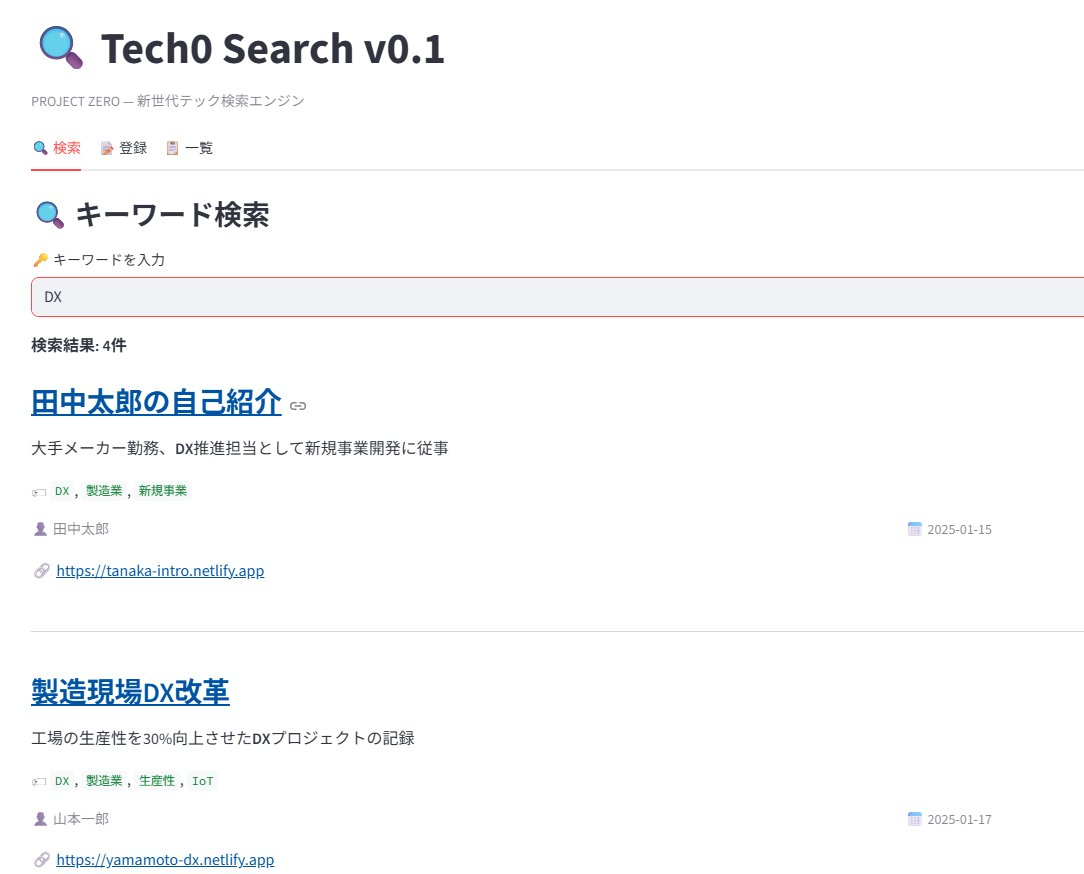


---

### 〈画面を3つのパーツに分解する〉

```
┌──────────────────────────────────────────────┐
│  ① タイトルエリア                             │
│     Tech0 Search v0.1                        │
│     PROJECT ZERO — 社内ナレッジ検索エンジン    │
├──────────────────────────────────────────────┤
│  ② タブエリア                                │
│     [ 検索 ]  [ 登録 ]  [ 一覧 ]             │
├──────────────────────────────────────────────┤
│  ③ コンテンツエリア（タブごとに中身が変わる）  │
│     検索タブ → 入力ボックス + 結果カード       │
│     登録タブ → 入力フォーム                   │
│     一覧タブ → 全件リスト                     │
└──────────────────────────────────────────────┘
```

このノートブックでは、この3つのパーツを作るための  
**「データ」「ロジック」「Streamlitコード」** を順番に学んでいきます。

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---
# Step 1：アプリの設計図を理解する

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈サブストーリー〉なぜ3つのファイルに分けるのか？

コンビニで例えると——

| ファイル | コンビニで例えると | 役割 |
|----------|-------------------|------|
| 🗄️ `pages.json` | **バックヤードの在庫棚** | データを保管する場所 |
| 🔪 `search.py` | **レジの計算システム** | 検索・ハイライトの処理ロジック |
| 🏪 `app.py` | **店舗の売り場レイアウト** | ユーザーが見て触る画面 |

1つのファイルに全部書くと100〜200行になって読めなくなります。  
役割ごとに分けることで「どこを直せばいいか」が一目でわかります。  
→ エンジニアはこれを **「関心の分離」** と呼びます。

---

### 〈3ファイルのデータの流れ〉

```
【ユーザーが「DX」と検索ボックスに入力する】
              ↓
         app.py が受け取る
              ↓
    search.py の search_pages() を呼ぶ
              ↓
       pages.json のデータと照合する
              ↓
    マッチしたページリストを app.py に返す
              ↓
    【画面に「検索結果：2件」と表示される】
```

### 〈フォルダ構成〉

```
techzero_w2/
├── app.py          # メインアプリ（Streamlit画面）
├── search.py       # 検索ロジック
├── data/
│   └── pages.json  # ページデータ（データベース代わり）
├── requirements.txt
└── README.md
```

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---
# Step 2：データの器「pages.json」を理解する

## 1-1. JSONとは何か？

##### JSON（ジェイソン）は「データを保存するためのテキストファイルのルール」です
##### Excelの表と同じように「データを整理して保存する入れ物」ですが、プログラムから読み書きしやすい形式です

##### 📌 今回のアプリでは `pages.json` に受講生のランディングページ情報を保存しています
##### 　　登録タブから新しいページを追加すると、このファイルに追記されます

##### まず「辞書（dict）」という概念を理解しましょう
##### 辞書とは「キー: 値」のペアでデータを整理するPythonの入れ物です

## ■ 写経（1）— 1件分のページデータを辞書で書く

##### `pages.json` の1件分のデータは、Python の「辞書（dict）」として表現されます
##### キーと値のペアを `"キー": 値` の形で並べることで、1人分のページ情報を表します

**このコードでやること：**
- `page = { ... }` という辞書を書いて実行する
- `page["title"]` のようにキーを指定して値を取り出す
- `page["keywords"][0]` でリストの中の最初の要素だけ取り出す

```
実行すると、こんな出力が得られます：
タイトル  ： 田中太郎の自己紹介
作者      ： 田中太郎
キーワード： ['DX', '製造業', '新規事業']
最初のKW  ： DX
```

**使う知識：** 辞書（dict）の定義 / `dict["キー"]` での値の取り出し / リストのインデックス参照


In [1]:
# pages.json の 1件分のデータを Python の「辞書（dict）」で書くとこうなる
# 「キー」: 「値」 の形でデータを整理する

page = {
    # ↓ ここにキーと値を書いてください
    "title":"田中太郎の自己紹介"
    "author":"田中太郎"
    "keywords":["DX","製造業","新規事業"]

}

# キーを指定して値を取り出す
# ↓ ここにコードを書いてください
print("タイトル":,page["title"])



SyntaxError: invalid syntax (2445684826.py, line 7)

##### 写経（模範解答）— 実際に書いてから確認しよう！

In [ ]:
# pages.json の 1件分のデータを Python の「辞書（dict）」で書くとこうなる
# 「キー」: 「値」 の形でデータを整理する

page = {
    "id"         : 1,
    "title"      : "田中太郎の自己紹介",
    "url"        : "https://tanaka-intro.netlify.app",
    "description": "大手メーカー勤務、DX推進担当として新規事業開発に従事",
    "keywords"   : ["DX", "製造業", "新規事業"],   # ← [ ] はリスト（複数の値）
    "author"     : "田中太郎",
    "created_at" : "2025-01-15",
    "category"   : "自己紹介",
}

# キーを指定して値を取り出す
print("タイトル  :", page["title"])
print("作者      :", page["author"])
print("キーワード:", page["keywords"])
print("最初のKW  :", page["keywords"][0])  # ← リストの0番目 = 最初の要素

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈サブストーリー〉この辞書の各キーが、画面のどこに表示されるか？

```
┌──────────────────────────────────────────────────────────┐
│                                                          │
│  ###  📄 田中太郎の自己紹介   ← page["title"]           │
│                                                          │
│  大手メーカー勤務、**DX**推進担当として...                │
│                           ↑ page["description"]         │
│                             （DXが太字なのはハイライト処理）│
│                                                          │
│  🏷 `DX`  `製造業`  `新規事業`  ← page["keywords"]     │
│                                                          │
│  👤 田中太郎         ← page["author"]                   │
│  📅 2025-01-15       ← page["created_at"]               │
│                                                          │
│  🔗 https://tanaka-intro.netlify.app ← page["url"]      │
│                                                          │
└──────────────────────────────────────────────────────────┘
```

**辞書の各「キー」が、画面のパーツと1対1で対応しています！**

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

## ■ 写経（2）— 複数件をリストにまとめる（pages.json の全体像）

##### 複数の辞書を「リスト（list）」にまとめると、`pages.json` の全体像になります
##### リストとは `[ ]` の中にデータを `,` で区切って並べたものです

**このコードでやること：**
- 辞書を複数まとめたリスト `pages = [ {...}, {...}, ... ]` を書いて実行する
- `len(pages)` で件数を確認する
- `for page in pages:` でループして全件のタイトルを表示する

```
実行すると、こんな出力が得られます：
登録件数： 3
1件目： 田中太郎の自己紹介
2件目： 製造現場DX改革
3件目： AIによる品質検査
```

**使う知識：** リスト（list）の定義 / `len()` / for ループ

##### ⚠️ Python の添字（番号）は **0から始まる** ことに注意！


In [ ]:
# 複数件のページをリストにまとめる = pages.json の全体像

pages = [
    # ↓ ここに辞書を , で区切って並べてください

]

# ↓ ここにコードを書いてください（件数表示・一覧表示）


##### 写経（模範解答）— 実際に書いてから確認しよう！

In [2]:
# 複数件のページをリストにまとめる = pages.json の全体像

pages = [
    {   # 1件目
        "id": 1, "title": "田中太郎の自己紹介",
        "description": "大手メーカー勤務、DX推進担当",
        "keywords": ["DX", "製造業"], "author": "田中太郎",
    },
    {   # 2件目
        "id": 2, "title": "スマート冷蔵庫プロジェクト",
        "description": "IoT技術を活用した次世代家電の企画提案",
        "keywords": ["IoT", "家電", "AI"], "author": "鈴木花子",
    },
    {   # 3件目
        "id": 3, "title": "製造現場DX改革",
        "description": "工場の生産性を30%向上させたDXプロジェクトの記録",
        "keywords": ["DX", "製造業", "生産性", "IoT"], "author": "山本一郎",
    },
]

print(f"登録件数      : {len(pages)} 件")          # len() でリストの長さを取得
print(f"1件目タイトル : {pages[0]['title']}")      # 添字 0 = 最初
print(f"2件目タイトル : {pages[1]['title']}")      # 添字 1 = 2番目
print(f"3件目タイトル : {pages[2]['title']}")      # 添字 2 = 3番目（0始まりに注意！）
print()
# 一覧表示
print("── 全件タイトル一覧 ──")
for i, p in enumerate(pages):           # enumerate で「番号付き」で取り出す
    print(f"  {i+1}件目: {p['title']}")

登録件数      : 3 件
1件目タイトル : 田中太郎の自己紹介
2件目タイトル : スマート冷蔵庫プロジェクト
3件目タイトル : 製造現場DX改革

── 全件タイトル一覧 ──
  1件目: 田中太郎の自己紹介
  2件目: スマート冷蔵庫プロジェクト
  3件目: 製造現場DX改革


## 1-2. JSONファイルを「読み込む」「書き込む」

##### プログラムを終了するとメモリ上のデータは消えてしまいます
##### ファイルに保存することで「アプリを再起動してもデータが残る」ようになります
##### → これを **データの永続化（えいぞくか）** といいます

## ■ 写経（3）— JSONファイルを読み込む

**このコードでやること：**
- `json.load()` を使って `pages.json` をファイルから読み込む
- 読み込んだデータが「辞書のリスト」として扱えることを確認する
- 件数と最初の1件のタイトルを表示する

```
実行すると、こんな出力が得られます：
読み込み件数： ○件
最初のタイトル： 田中太郎の自己紹介
```

**使う知識：** `import json` / `with open(...) as f:` / `json.load(f)`


In [7]:
# json ライブラリ：Python に最初から入っているJSONを扱うための道具
# pip install 不要！
# ↓ import json を書いてください
import json


# ── JSONファイルを「読み込む」──
# これが app.py の load_pages() 関数がやっていることです
# ※ pages.json をこのノートブックと同じフォルダに置いてから実行してください
with open("pages.json", "r", encoding="utf-8") as f:
    loaded_pages = json.load(f)

# ↓ with open(...) as f: と json.load(f) で読み込んでください
#   ファイル名: "pages.json" / モード: "r" / encoding="utf-8"


# ↓ 件数表示・タイトル一覧を書いてください
print(f"読み込んだ件数: {len(loaded_pages)} 件")
print()
print("── 全件のタイトル一覧 ──")
for i, p in enumerate(loaded_pages):
    print(f"  {i+1}件目: {p['title']}  （{p['author']}）")

読み込んだ件数: 5 件

── 全件のタイトル一覧 ──
  1件目: 田中太郎の自己紹介  （田中太郎）
  2件目: スマート冷蔵庫プロジェクト  （鈴木花子）
  3件目: 製造現場DX改革  （山本一郎）
  4件目: AIで変わるビジネスの未来  （佐藤美咲）
  5件目: ヘルスケアDXプラットフォーム  （中村健太）


##### 写経（模範解答）— 実際に書いてから確認しよう！

In [4]:
# json ライブラリ：Python に最初から入っているJSONを扱うための道具
# pip install 不要！
import json

# ── JSONファイルを「読み込む」──
# これが app.py の load_pages() 関数がやっていることです

# ※ pages.json をこのノートブックと同じフォルダに置いてから実行してください
with open("pages.json", "r", encoding="utf-8") as f:
    #        ↑ファイル名   ↑「r」=読む(read)  ↑日本語を正しく読むための設定
    loaded_pages = json.load(f)   # ← ファイルの中身をPythonのリストとして読み込む

print(f"読み込んだ件数: {len(loaded_pages)} 件")
print()
print("── 全件のタイトル一覧 ──")
for i, p in enumerate(loaded_pages):
    print(f"  {i+1}件目: {p['title']}  （{p['author']}）")

読み込んだ件数: 5 件

── 全件のタイトル一覧 ──
  1件目: 田中太郎の自己紹介  （田中太郎）
  2件目: スマート冷蔵庫プロジェクト  （鈴木花子）
  3件目: 製造現場DX改革  （山本一郎）
  4件目: AIで変わるビジネスの未来  （佐藤美咲）
  5件目: ヘルスケアDXプラットフォーム  （中村健太）


ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈サブストーリー〉`with open(...) as f:` の「with」は何のため？

ファイルを開く操作は **「金庫を開ける」** ようなものです。

- ❌ **悪い例**：金庫を開けたまま作業して **閉め忘れる** → データが壊れる危険がある
- ✅ **良い例**：`with` 構文を使うと、作業が終わったら **自動的に閉じてくれる**

```python
with open("pages.json", "r", encoding="utf-8") as f:
    #                   ↑               ↑
    #              "r" = 読む         日本語を正しく読む
    data = json.load(f)   # ← ここでファイルを読む
# ← ここに来ると自動的にファイルが閉じる
```

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

## ■ 写経（4）— JSONファイルに書き込む

**このコードでやること：**
- `test_data`（書き込みテスト用のリスト）を用意する
- `json.dump()` を使って `test_output.json` というファイルに書き込む
- 書き込んだファイルを再読み込みして、中身が正しく保存されているか確認する

```
実行すると、こんな出力が得られます：
書き込み完了！ test_output.json の中身：
[
  {
    "id": 99,
    "title": "テスト書き込みページ",
    ...
  }
]
```

**使う知識：** `json.dump()` / `"w"`（書き込みモード） / `ensure_ascii=False`（日本語を文字化けさせない） / `indent=2`（見やすく整形）

> ⚠️ このコードは `test_output.json` という**テスト用ファイル**に書き込みます。  
> `pages.json` は変更されないので、安心して実行してください。


In [ ]:
# ── JSONファイルに「書き込む」──
# これが app.py の save_pages() 関数がやっていることです
# 「登録タブ」でフォームを送信したとき、この処理が走ります

test_data = [
    {
        "id": 99,
        "title": "テスト書き込みページ",
        "description": "このデータは書き込みテスト用です",
        "keywords": ["テスト", "Python"],
        "author": "受講生",
    }
]
with open("test_")


# ↓ with open(...) as f: で "test_output.json" を "w" モードで開いて
#   json.dump() で書き込んでください（ensure_ascii=False / indent=2）


# ↓ 書き込んだ内容を確認してください（with open で読み込んで print）


##### 写経（模範解答）— 実際に書いてから確認しよう！

In [8]:
# ── JSONファイルに「書き込む」──
# これが app.py の save_pages() 関数がやっていることです
# 「登録タブ」でフォームを送信したとき、この処理が走ります

test_data = [
    {
        "id": 99,
        "title": "テスト書き込みページ",
        "description": "このデータは書き込みテスト用です",
        "keywords": ["テスト", "Python"],
        "author": "受講生",
    }
]

with open("test_output.json", "w", encoding="utf-8") as f:
    #                          ↑
    #              "w" = 書く（write）
    json.dump(test_data, f, ensure_ascii=False, indent=2)
    #                        ↑                   ↑
    #               日本語をそのまま保存       見やすく整形して保存

# 書き込んだ内容を確認
with open("test_output.json", "r", encoding="utf-8") as f:
    content = f.read()

print("書き込み完了！ test_output.json の中身：")
print(content)

書き込み完了！ test_output.json の中身：
[
  {
    "id": 99,
    "title": "テスト書き込みページ",
    "description": "このデータは書き込みテスト用です",
    "keywords": [
      "テスト",
      "Python"
    ],
    "author": "受講生"
  }
]


---
# Step 3：検索ロジック「search.py」を理解する

## 2-1. 関数（def）とは何か？

##### 関数とは「繰り返し使える処理のかたまり」に名前をつけたものです

##### 自動販売機に例えると——
- 🪙 **コイン（引数）** を入れて
- 🔘 **ボタン（関数名）** を押すと
- 🥤 **ジュース（戻り値）** が出てくる

##### search.py には2つの関数があります

| 関数名 | 入れるもの（引数） | 出てくるもの（戻り値） | 画面での役割 |
|--------|--------------------|----------------------|--------------|
| `search_pages()` | キーワード＋ページリスト | マッチしたページのリスト | 「検索結果：2件」を作る |
| `highlight_match()` | テキスト＋キーワード | **太字**になったテキスト | 説明文の DX → **DX** |

## ■ 写経（5）— 関数の基本を理解する

##### まず `search_pages()` より簡単な関数で「関数とは何か」の構造を体で覚えます

**このコードでやること：**
- `def 関数名(引数):` の書き方で、シンプルな `say_hello()` 関数を定義する
- 定義した関数を呼び出して、引数によって出力が変わることを確認する
- `return` で値を返す関数と、`print()` するだけの関数の違いを確認する

```
実行すると、こんな出力が得られます：
こんにちは、田中さん！
こんにちは、鈴木さん！
```

**使う知識：** `def` による関数定義 / 引数 / `return` / 関数呼び出し


In [15]:
# 【関数の基本】まずシンプルな例で構造を理解しよう

def say_hello(name):                      # def 関数名(引数): で定義する
    message = f"こんにちは、{name}さん！"
    return message


# 関数を「呼び出す」
result1 = say_hello("田中太郎")
result2 = say_hello("鈴木花子")

print(result1)
print(result2)
# ↓ ここにコードを書いてください
# → 同じ関数を何度でも「別の引数」で使い回せる。これが関数のメリット！


こんにちは、田中太郎さん！
こんにちは、鈴木花子さん！


##### 写経（模範解答）— 実際に書いてから確認しよう！

In [10]:
# 【関数の基本】まずシンプルな例で構造を理解しよう

def say_hello(name):                      # def 関数名(引数): で定義する
    message = f"こんにちは、{name}さん！" # 処理内容（インデント必須）
    return message                         # return で戻り値を返す

# 関数を「呼び出す」
result1 = say_hello("田中太郎")
result2 = say_hello("鈴木花子")

print(result1)
print(result2)
# → 同じ関数を何度でも「別の引数」で使い回せる。これが関数のメリット！

こんにちは、田中太郎さん！
こんにちは、鈴木花子さん！


## 2-2. `search_pages()` を読み解く

##### この関数が「検索結果：2件」という表示を生み出しています

```
┌─────────────────────────────────────────────┐
│  キーワードを入力                            │
│  ┌───────────────────────────────────────┐  │
│  │ DX                                    │  │ ← query = "DX"
│  └───────────────────────────────────────┘  │
│                                             │
│  検索結果：2件    ← len(search_pages(...))  │
└─────────────────────────────────────────────┘
```

## ■ 写経（6）— search_pages() の全体

**このコードでやること：**
- `search_pages(query, pages)` 関数を丸ごと写して定義する
- `"DX"` で検索してヒット件数と各タイトルを表示する
- `"dx"`（小文字）でも同じ結果になることを `.lower()` の効果として確認する

```
実行すると、こんな出力が得られます：
'DX' の検索結果： 2件
  - 田中太郎の自己紹介
  - 製造現場DX改革
'dx' の検索結果： 2件  ← 小文字でも同じ結果！
```

**使う知識：** for ループ / if 文 / `.lower()` / `list.append()` / `return`


In [17]:
# search_pages() の全体 — コメントを手がかりに自分で書いてみよう

def search_pages(query: str, pages: list) -> list:
    # ↑ 「: str」「: list」は型ヒント / 「-> list」は戻り値の型宣言

    # ① キーワードが空欄ならすぐ終了（空リストを返す）
    # ↓ ここにコードを書いてください
    if not query.strip():
        return[]

    # ② 結果を入れる空のリストを用意
    # ↓ ここにコードを書いてください

    # ③ query を小文字に統一（.lower() を使う）
    # ↓ ここにコードを書いてください

    # ④ ページを1件ずつ取り出してループ（for ループ）
    # ↓ ここにコードを書いてください

        # ⑤ title + description + keywords を1つの文字列に結合
        # ↓ ここにコードを書いてください

        # ⑥ キーワードが含まれていたら results に追加（.append() を使う）
        # ↓ ここにコードを書いてください

    # ⑦ マッチしたページのリストを return する
    # ↓ ここにコードを書いてください


# ── 実際に動かしてみよう ──
import json
with open("pages.json", "r", encoding="utf-8") as f:
    all_pages = json.load(f)

# ↓ 「DX」で検索して結果を表示してください


##### 写経（模範解答）— 実際に書いてから確認しよう！

In [16]:
# search_pages() の全体 — 1行ずつコメントで解説

def search_pages(query: str, pages: list) -> list:
    # ↑ 「: str」「: list」は型ヒント（なくても動くが読みやすくなる）
    # ↑ 「-> list」は「戻り値はリスト型」という宣言

    # ① キーワードが空欄ならすぐ終了（空リストを返す）
    if not query.strip():
        #  ↑ .strip() は前後の空白を取り除く
        #  ↑ not は「〜でない」 → 空欄なら True になる
        return []

    results = []                    # ② 結果を入れる空のリストを用意
    query_lower = query.lower()    # ③ "DX" → "dx" と小文字に統一（大文字小文字を無視するため）

    for page in pages:              # ④ ページを1件ずつ取り出してループ

        # ⑤ title + description + keywords を1つの文字列に結合して検索対象にする
        search_text = " ".join([
            page["title"],
            page["description"],
            " ".join(page["keywords"]),  # ["DX","製造業"] → "DX 製造業"
        ])
        # 例: "田中太郎の自己紹介 大手メーカー勤務、DX推進担当 DX 製造業 新規事業"

        # ⑥ キーワードが search_text に含まれていたら results に追加
        if query_lower in search_text.lower():
            results.append(page)    # .append() でリストに追加

    return results  # ⑦ マッチしたページのリストを返す


# ── 実際に動かしてみよう ──
import json
with open("pages.json", "r", encoding="utf-8") as f:
    all_pages = json.load(f)

hits = search_pages("DX", all_pages)
print(f"'DX' の検索結果: {len(hits)} 件")
print()
for h in hits:
    print(f"  ✅ {h['title']}  （{h['author']}）")

'DX' の検索結果: 4 件

  ✅ 田中太郎の自己紹介  （田中太郎）
  ✅ 製造現場DX改革  （山本一郎）
  ✅ AIで変わるビジネスの未来  （佐藤美咲）
  ✅ ヘルスケアDXプラットフォーム  （中村健太）


ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈サブストーリー〉for ループの動きを図解する

```
pages = [田中さん, 鈴木さん, 山本さん, 佐藤さん, 中村さん]  （5件登録済み）

for page in pages:
    ↓ 1周目: page = 田中さんデータ →「DX」含む？ → ✅ → results に追加
    ↓ 2周目: page = 鈴木さんデータ →「DX」含む？ → ❌ → スキップ
    ↓ 3周目: page = 山本さんデータ →「DX」含む？ → ✅ → results に追加
    ↓ 4周目: page = 佐藤さんデータ →「DX」含む？ → ✅ → results に追加
    ↓ 5周目: page = 中村さんデータ →「DX」含む？ → ❌ → スキップ

return [田中さん, 山本さん, 佐藤さん]  ← 検索結果：3件
```

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈サブストーリー〉`.lower()` がなぜ必要か？

`search_pages()` の中に `query_lower = query.lower()` という行があります。  
これは **「大文字・小文字を区別しないで検索する」** ための処理です。

たとえば受講生が `dx` と小文字で入力しても `DX` を含むページをヒットさせたい。  
`.lower()` がないと、これができません。次のセルで実際に確認してみましょう。


In [ ]:
# 【検証】.lower() があるとないとでは何が変わるか体験する

description = "DX推進担当として新規事業開発に従事"

# lower() なし：大文字・小文字が違うと一致しない
print("── lower() なし ──")
print("'DX' in text :",")
# ↓ ここにコードを書いてください


# lower() あり：すべて小文字に揃えて比較するので確実に見つかる
print("── lower() あり ──")
# ↓ ここにコードを書いてください


##### 写経（模範解答）— 実際に書いてから確認しよう！

In [18]:
# 【検証】.lower() があるとないとでは何が変わるか体験する

description = "DX推進担当として新規事業開発に従事"

# lower() なし：大文字・小文字が違うと一致しない
print("── lower() なし ──")
print("'DX' in text :", "DX" in description)   # True
print("'dx' in text :", "dx" in description)   # False ← 見つからない！
print()

# lower() あり：すべて小文字に揃えて比較するので確実に見つかる
print("── lower() あり ──")
print("'DX' in text :", "DX".lower() in description.lower())  # True
print("'dx' in text :", "dx".lower() in description.lower())  # True ← 見つかる！

── lower() なし ──
'DX' in text : True
'dx' in text : False

── lower() あり ──
'DX' in text : True
'dx' in text : True


## 2-3. `highlight_match()` を読み解く

##### この関数が「説明文の中の DX を **太字** に変える」処理をしています

```
変換前: 大手メーカー勤務、DX推進担当として新規事業開発に従事

変換後: 大手メーカー勤務、**DX**推進担当として新規事業開発に従事
                          ↑
            Streamlit画面では「太字」で表示される
```

##### `re`（正規表現）というライブラリを使って「特定パターンの文字列を検索・置換」します

## ■ 写経（7）— highlight_match() の全体

**このコードでやること：**
- `highlight_match(text, query)` 関数を丸ごと写して定義する
- 説明文に対してキーワードを渡すと `**キーワード**` に変換されることを確認する
- 大文字 `"DX"` でも小文字 `"dx"` でも同じ結果になることを確認する

```
実行すると、こんな出力が得られます：
【変換前】
  大手メーカー勤務、DX推進担当として新規事業開発に従事
【変換後 DX】
  大手メーカー勤務、**DX**推進担当として新規事業開発に従事
【変換後 dx】
  大手メーカー勤務、**dx**推進担当として新規事業開発に従事
```

**使う知識：** `import re` / `re.compile()` / `re.IGNORECASE` / `pattern.sub()`


In [2]:
import re  # re = Regular Expression（正規表現）標準ライブラリ、pip install 不要

def highlight_match(text: str, query: str) -> str:

    if not query:       # キーワードが空なら何もしない
        return text

    # re.compile() でパターンを作る
    pattern = re.compile(
        re.escape(query),
        re.IGNORECASE
    )
    # re.escape(query) で特殊文字を安全に扱う / re.IGNORECASE で大文字小文字を区別しない
    # ↓ ここにコードを書いてください


    # pattern.sub(置換後, 元テキスト) でマッチ部分を置換する
    return pattern.sub(f"**{query}**", text)
    # 「**DX**」← Markdown で ** で囲むと太字になる
    # ↓ ここにコードを書いてください（return も含む）


# ── 動かしてみよう ──
original = "大手メーカー勤務、DX推進担当として新規事業開発に従事"
result1 = highlight_match(original,"DX")
result2 = highlight_match(original,"dx")

print("【変換前】")   ; print(" ", original)
print("【変換後 DX】") ; print(" ", result1)
print("【変換後 dx】") ; print(" ", result2)
print()
print("※ Streamlit画面では **DX** の部分が太字で表示されます")
# ↓ DX・dx で変換して結果を print してください



【変換前】
  大手メーカー勤務、DX推進担当として新規事業開発に従事
【変換後 DX】
  大手メーカー勤務、**DX**推進担当として新規事業開発に従事
【変換後 dx】
  大手メーカー勤務、**dx**推進担当として新規事業開発に従事

※ Streamlit画面では **DX** の部分が太字で表示されます


##### 写経（模範解答）— 実際に書いてから確認しよう！

In [ ]:
import re  # re = Regular Expression（正規表現）標準ライブラリ、pip install 不要

def highlight_match(text: str, query: str) -> str:

    if not query:       # キーワードが空なら何もしない
        return text

    # re.compile() でパターン（検索ルール）を作る
    pattern = re.compile(
        re.escape(query),  # re.escape：「?」「+」などの特殊文字が含まれても壊れない安全策
        re.IGNORECASE      # IGNORECASE：大文字・小文字を区別しない
    )

    # pattern.sub(置換後の文字列, 元テキスト)：マッチした部分を置換する
    return pattern.sub(f"**{query}**", text)
    #                  ↑
    #   「**DX**」← Markdown で ** で囲むと太字になる！


# ── 動かしてみよう ──
original = "大手メーカー勤務、DX推進担当として新規事業開発に従事"
result1  = highlight_match(original, "DX")
result2  = highlight_match(original, "dx")   # 小文字でもOK（IGNORECASE のおかげ）

print("【変換前】")   ; print(" ", original)
print("【変換後 DX】") ; print(" ", result1)
print("【変換後 dx】") ; print(" ", result2)
print()
print("※ Streamlit画面では **DX** の部分が太字で表示されます")

---
## ✅ Step 3 まとめ — Jupyter で学んだ関数を `search.py` に書き出そう

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

Step 3 では Jupyter 上で **2つの関数** を理解しました。

| 関数 | 役割 |
|------|------|
| `search_pages(query, pages)` | キーワードでページを絞り込む |
| `highlight_match(text, query)` | 説明文のキーワードを太字にする |

この2つは **Jupyter の中だけで動く練習コード** です。  
Streamlit アプリ（`app.py`）から使うには、**`search.py` というファイルに書き出す**必要があります。

```
Jupyter（このノートブック）             search.py
─────────────────────────────   →   ──────────────────────────────
search_pages() を理解した         →   search.py に同じ関数を書く
highlight_match() を理解した      →   search.py に同じ関数を書く
                                               ↓
                                     app.py から
                                     from search import search_pages, highlight_match
                                     で呼び出して使う
```

> 💡 Jupyter で「動く」を確認したコードをそのままコピーして `search.py` に貼れば OK です。  
> 新しいことを覚える必要はありません。**場所を移すだけ**です。

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---
# Step 4：Streamlit 作成のエッセンスを学ぶ

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

## 4-1. Streamlit とは何か？

##### Streamlit（ストリームリット）は「Python コードだけで Web アプリを作れるライブラリ」です

| 普通の Web アプリ開発 | Streamlit なら |
|----------------------|---------------|
| HTML＋CSS＋JavaScriptの3言語が必要 | **Python だけ** で OK |
| 最低でも数週間〜数ヶ月の学習が必要 | 今日から始められる |

##### Streamlit の最大の特徴は「**コードを上から下に書くだけで画面が作られる**」ことです

```python
# これだけで画面が作れる！
import streamlit as st
st.title('Hello, Tech0!')   # → 大きいタイトルが画面に表示される
st.write('こんにちは')      # → テキストが表示される
```

> ⚠️ **注意**：Streamlit のコードはこのノートブック内では画面表示できません。  
> 「どんなコードを書けば何が表示されるか」を理解することが目的です。  
> 実際の動作確認は自分で `app.py` を作って `streamlit run app.py` で行います。

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

## 4-2. 【画面 × コード 対応マップ】

##### 実際の画面の各パーツが、どのコードで作られているかを確認しましょう
##### 矢印の先のコードが、その画面パーツを生み出しています

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー


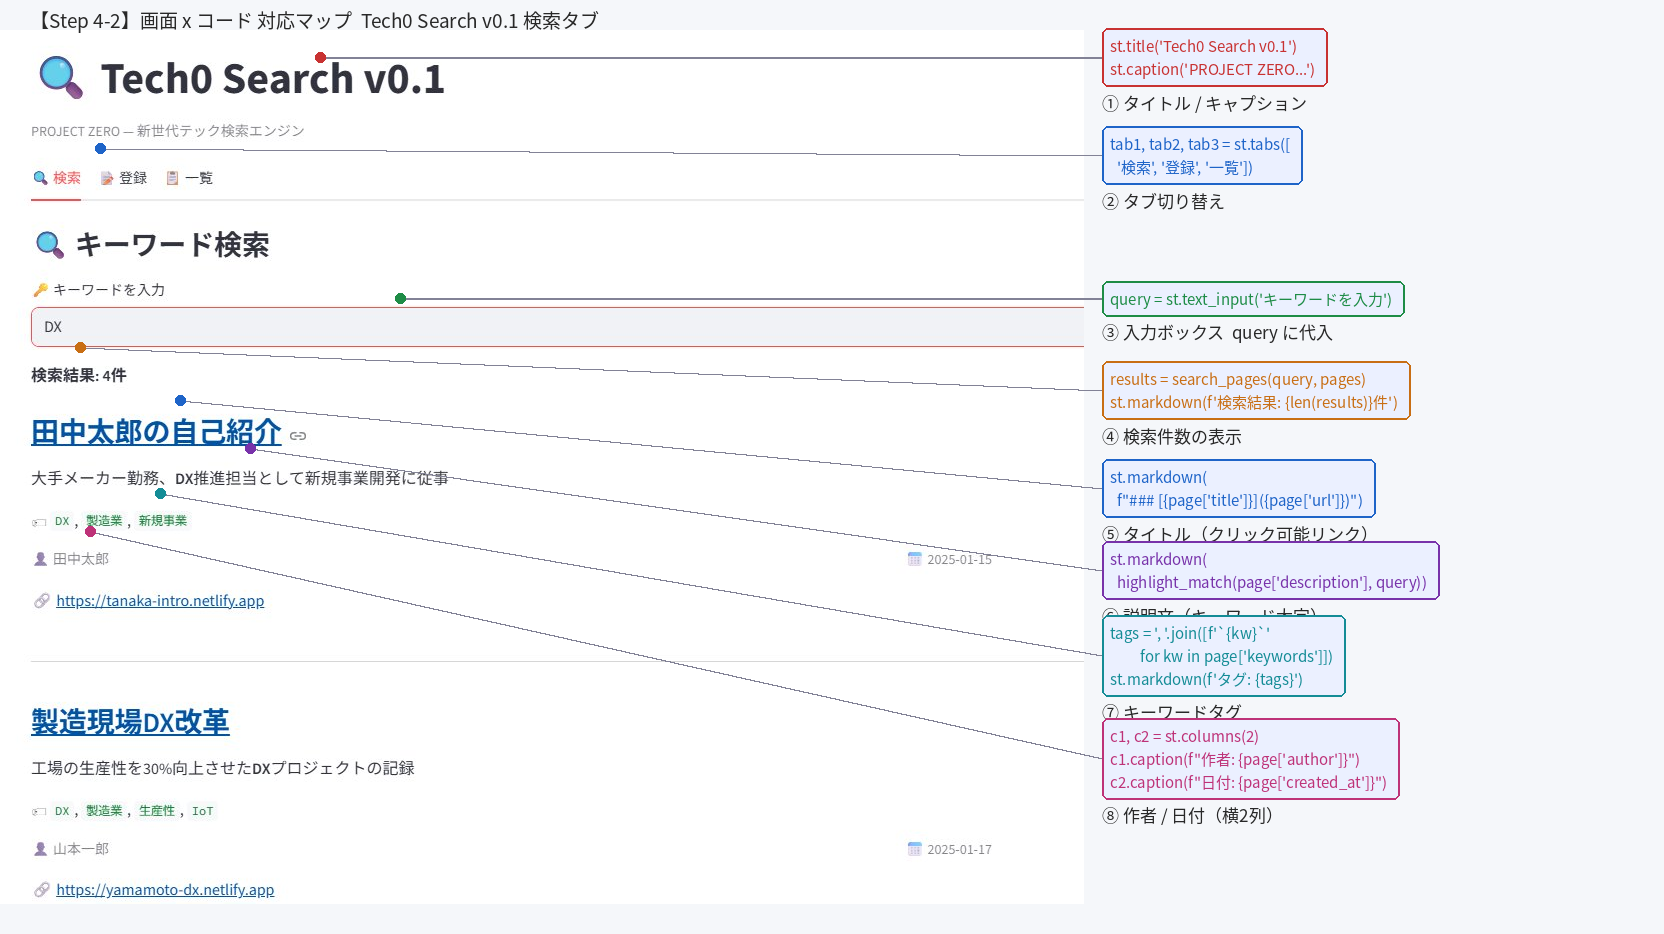



> 💡 **ポイント**  
> 全部を一度に覚える必要はありません。  
> 「この部分を変えたい」と思ったとき、この図に戻って確認しましょう。

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

## 4-3. Streamlit 主要コマンド早見表

##### app.py を自分で書くときに必要なコマンドをまとめました
##### コードブロックは「読むだけ」です。実際の動作は `app.py` に書いて試しましょう

---

### 【表示系】テキストを画面に出す

```python
st.title('大きなタイトル')        # 一番大きい見出し  → 「Tech0 Search v0.1」
st.subheader('中見出し')          # 中くらいの見出し  → 「キーワード検索」
st.caption('小さい補足テキスト')  # 小さいテキスト   → 「PROJECT ZERO —...」
st.markdown('**太字** や *斜体*') # Markdown記法で装飾 → ハイライトされた説明文
st.divider()                      # 横線を引く        → 検索結果の区切り線
```

---

### 【入力受付系】ユーザーの操作を受け取る

```python
query = st.text_input('キーワードを入力')      # テキスト入力ボックス → 検索ボックス
text  = st.text_area('説明')                   # 複数行テキスト入力   → 登録フォームの説明欄
opt   = st.selectbox('カテゴリ', ['A', 'B'])   # ドロップダウン選択   → カテゴリ選択
```

---

### 【レイアウト系】画面の構造を作る

```python
# タブを作る
tab1, tab2, tab3 = st.tabs(['検索', '登録', '一覧'])
with tab1:
    st.write('検索タブの中身')   # インデント内が検索タブの内容になる

# 横2列に分割する → 作者と日付を左右に並べる
col1, col2 = st.columns(2)
col1.caption('田中太郎')
col2.caption('2025-01-15')

# アコーディオン（クリックで開閉）
with st.expander('田中太郎の自己紹介'):
    st.write('中身')
```

---

### 【フォーム系】まとめて送信できる入力エリアを作る

```python
with st.form('register_form'):           # フォームを作る
    url       = st.text_input('URL')
    title     = st.text_input('タイトル')
    submitted = st.form_submit_button('登録する')   # 送信ボタン

if submitted:                             # 送信ボタンが押されたとき
    st.success('登録完了！')              # 緑の成功メッセージ
    st.error('URLは必須です')             # 赤のエラーメッセージ
```

---

### 【キャッシュ】データ読み込みを高速化する

```python
@st.cache_data                    # このデコレータを付けるだけ
def load_pages():
    with open('pages.json', ...) as f:
        return json.load(f)
# 1回目だけファイルを読んで、2回目以降はメモリの値を使い回す（高速化）
# 登録後にデータを更新するには st.cache_data.clear() でキャッシュをリセット
```

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

## 4-4. app.py を自分で書くときの骨格

##### Step 2・3 で学んだJSON操作・検索ロジックが app.py の中でこう使われます
##### 「どの順番で何を書くか」の骨格を示します

```python
# ① ライブラリのインポート
import streamlit as st
import json
from search import search_pages, highlight_match   # Step3 で学んだ関数！

# ② データの読み書き関数（Step2 で学んだ json.load / json.dump を使う）
@st.cache_data
def load_pages(): ...
def save_pages(pages): ...

# ③ ページ設定・タイトル
st.set_page_config(page_title='Tech0 Search v0.1')
st.title('...')

# ④ タブを作る
tab1, tab2, tab3 = st.tabs(['検索', '登録', '一覧'])
pages = load_pages()

# ⑤ 検索タブ
with tab1:
    query = st.text_input('キーワードを入力')
    if query:
        results = search_pages(query, pages)           # Step3 の関数をそのまま使う！
        for page in results:
            st.markdown(highlight_match(               # Step3 の関数をそのまま使う！
                page['description'], query))

# ⑥ 登録タブ
with tab2:
    with st.form('register_form'):
        ...    # 入力フィールドを作る
        submitted = st.form_submit_button('登録する')
    if submitted:
        pages.append(new_page)
        save_pages(pages)          # Step2 で学んだ json.dump を使う！
        st.cache_data.clear()
        st.rerun()                 # 画面を再読み込みして一覧に反映

# ⑦ 一覧タブ
with tab3:
    for page in pages:
        with st.expander(page['title']):
            ...    # ページ情報を表示
```

> 💡 **Step 2・3 で書いたコードがそのまま活躍します！**  
> `search.py` に書いた2つの関数は `from search import ...` の1行で読み込めます。

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

## 4-5. 登録処理のポイント — `st.rerun()` と `st.cache_data.clear()`

##### 登録ボタンを押した後、一覧にどうやって反映されるのか？

```
【登録ボタンが押されたときの流れ】

① new_page = { ... }        新しいページ辞書を作る
       ↓
② pages.append(new_page)    リストに追加する
       ↓
③ save_pages(pages)         pages.json に保存する（Step2 の json.dump）
       ↓
④ st.cache_data.clear()     古いキャッシュを捨てる
       ↓
⑤ st.rerun()                画面を再読み込みする
       ↓
⑥ load_pages() が再実行     新しいデータを読み込む
       ↓
【一覧タブに新しいページが表示される！】
```

##### `st.rerun()` を忘れると、登録後も古いデータのままになるので注意！

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---

## 4-6. 📚 Streamlit 公式ドキュメントを活用しよう

##### このノートブックで紹介したのはほんの一部です
##### 「こんな機能を追加したい」と思ったら、まず公式ドキュメントで検索してみましょう

| ドキュメント | URL |
|------------|-----|
| API リファレンス（全コマンド一覧） | https://docs.streamlit.io/develop/api-reference |
| コンポーネントギャラリー | https://streamlit.io/components |
| チートシート | https://cheat-sheet.streamlit.app |

> `st.` と打つと補完候補がたくさん出てきます。どんどん試してみてください！

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---
## 4-7. いよいよ `app.py` を書こう！

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 〈どのファイルに何を書くか — 全体マップ〉

```
techzero_w2/                   ← Streamlit アプリ用フォルダ（新しく作る）
│
├── search.py        ◀ Step3 で学んだ2つの関数をここに書く
│     ├── search_pages()              # Step3-2 で学んだ検索関数
│     └── highlight_match()           # Step3-3 で学んだハイライト関数
│
├── app.py           ◀ 自分で書く！（Step4 の骨格・コマンド早見表を参考に）
│     ├── from search import ...      # search.py の関数を読み込む
│     ├── load_pages() / save_pages() # Step2 で学んだ json.load / json.dump
│     ├── st.tabs()                   # 検索・登録・一覧の3タブ
│     ├── tab1: 検索タブ              # search_pages() + highlight_match() を使う
│     ├── tab2: 登録タブ              # st.form() + save_pages() + st.rerun()
│     └── tab3: 一覧タブ              # 全件ループ表示
│
├── requirements.txt ◀ アプリに必要なライブラリを記載する
│     └── 中身： streamlit>=1.32.0
│
└── pages.json       ◀ week2-notebook/ からコピーする
```

---

### 〈Jupyter とアプリフォルダの役割の違い〉

| このノートブック（Jupyter） | tech0-search/（アプリフォルダ） |
|---------------------------|--------------------------------|
| コードを **理解する** 場所 | コードを **動かす** 場所 |
| 1セルずつ実行して確認する | `streamlit run app.py` で一括起動 |
| 練習・実験用 | 成果物・提出用 |

---

### 〈作業手順〉

```
① tech0-search/ フォルダを新しく作る
       ↓
② search.py を作る
   Step3 の search_pages() と highlight_match() をそのままコピーして貼る
       ↓
③ requirements.txt を作る
   中身に「streamlit>=1.32.0」と書いて保存する
       ↓
④ pages.json を week2-notebook/ からコピーする
       ↓
⑤ app.py を書く  ← ここが今週のメイン！
   Step4-4「app.py を書くときの骨格」を参考にしながら自分で作る
       ↓
⑥ ターミナルでライブラリをインストールする
   pip install -r requirements.txt
       ↓
⑦ Step5 の練習問題で理解を確認する
       ↓
⑧ Step6 で streamlit run app.py を実行して動かす！
```

> 💡 **迷ったときは**  
> 「Jupyter で動いた」→ そのコードを `.py` ファイルに書き出す、これだけです。  
> 4-4 の骨格と 4-3 のコマンド早見表を手元に置きながら進めましょう。

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

---
# Step 5：練習問題で総まとめ

## ■ 練習問題

ここまでで学んだJSON操作・関数・検索ロジック・Streamlit構造を使って問題を解きましょう！

---
##### 練習1

`pages.json` を読み込んで、**カテゴリが「プロダクト」のページだけ** タイトルと作者を表示してください。

```
期待する出力例：
カテゴリ: プロダクト のページ一覧
────────────────────────────────────────
  1件目: （タイトル）  （作者）
  2件目: ...
合計: ○ 件
```

**使う知識：** `json.load()` / for ループ / `page["category"]` の条件分岐


> 💡 **ヒント**：練習3を複数回実行していると `KeyError` が出ることがあります。  
> その場合は配布された元の `pages.json` に差し替えてから再実行してください。


In [8]:
import json

# pages.json を読み込む
with open("pages.json", "r", encoding="utf-8") as f:
    pages = json.load(f)

print("カテゴリ: プロダクト のページ一覧")
print("────────────────────────────────────────")

count = 0

# ページを1件ずつチェック
for page in pages:
    if page["category"] == "プロダクト":
        count += 1
        print(f"  {count}件目: {page['title']}  {page['author']}")

print(f"合計: {count} 件")

カテゴリ: プロダクト のページ一覧
────────────────────────────────────────
  1件目: スマート冷蔵庫プロジェクト  鈴木花子
  2件目: ヘルスケアDXプラットフォーム  中村健太
合計: 2 件


##### 練習1 の模範解答（自分で考えてから開こう！）

In [9]:
# ── 練習1 模範解答 ──
import json

with open('pages.json', 'r', encoding='utf-8') as f:
    pages = json.load(f)

print('カテゴリ: プロダクト のページ一覧')
print('-' * 40)
count = 0
for page in pages:
    if page.get('category', '') == 'プロダクト':
        count += 1
        print(f"  {count}件目: {page['title']}  （{page['author']}）")
print(f'\n合計: {count} 件')


カテゴリ: プロダクト のページ一覧
----------------------------------------
  1件目: スマート冷蔵庫プロジェクト  （鈴木花子）
  2件目: ヘルスケアDXプラットフォーム  （中村健太）

合計: 2 件


---
##### 練習2

`search_pages()` を使って **「IoT」で検索し**、ヒットした各ページの  
タイトル・作者・キーワードを表示してください。

```
期待する出力例：
'IoT' の検索結果: ○ 件
────────────────────────────────────────
  タイトル  : （タイトル）
  作者      : （作者）
  キーワード: DX, 製造業, IoT
```

**使う知識：** Step3 で定義した `search_pages()` / for ループ


In [ ]:
# 練習2 の解答欄
import json

with open('pages.json', 'r', encoding='utf-8') as f:
    pages = json.load(f)

# search_pages() を定義（Step3 で学んだ関数）
def search_pages(query, pages):
    
    if not query = query.lower():
    # ↓ ここにコードを書いてください


# ↓ ここにコードを書いてください（「IoT」で検索して結果を表示）


##### 練習2 の模範解答（自分で考えてから開こう！）

In [10]:
# ── 練習2 模範解答 ──
import json

with open('pages.json', 'r', encoding='utf-8') as f:
    pages = json.load(f)

def search_pages(query, pages):
    if not query.strip():
        return []
    results = []
    query_lower = query.lower()
    for page in pages:
        search_text = ' '.join([
            page['title'],
            page['description'],
            ' '.join(page['keywords']),
        ])
        if query_lower in search_text.lower():
            results.append(page)
    return results

hits = search_pages('IoT', pages)
print(f"'IoT' の検索結果: {len(hits)} 件")
print('-' * 40)
for h in hits:
    print(f"  タイトル  : {h['title']}")
    print(f"  作者      : {h['author']}")
    print(f"  キーワード: {', '.join(h['keywords'])}")
    print()


'IoT' の検索結果: 2 件
----------------------------------------
  タイトル  : スマート冷蔵庫プロジェクト
  作者      : 鈴木花子
  キーワード: IoT, 家電, AI, データ活用

  タイトル  : 製造現場DX改革
  作者      : 山本一郎
  キーワード: DX, 製造業, 生産性, IoT



---
##### 練習3

**自分自身の情報**で新しいページ辞書を作り、`pages.json` に追記してください。  
実行後は `pages.json` を直接開いて、自分のデータが追加されているか確認しましょう。

```
設定する項目：
  url         : あなたのLP URL
  title       : ページタイトル
  description : 説明文
  keywords    : キーワードのリスト
  author      : あなたの名前
  category    : カテゴリ名
```

**使う知識：** `json.load()` / 辞書の作成 / `list.append()` / `json.dump()`


> ⚠️ **注意**：このセルを実行するたびに `pages.json` に1件追加されます。  
> 複数回実行すると同じデータが重複して登録されます。  
> 練習1を実行したときに `KeyError` が出た場合は、配布された元の `pages.json` に差し替えてから再実行してください。


In [ ]:
# 練習3 の解答欄
import json
from datetime import datetime

with open('pages.json', 'r', encoding='utf-8') as f:
    pages = json.load(f)

# 新しいページ辞書を作る（★自分の情報に書き換えてください）
new_page = {
    # ↓ ここにキーと値を書いてください
}

# ↓ ここにコードを書いてください（追加・保存・確認）


##### 練習3 の模範解答（自分で考えてから開こう！）

In [11]:
# ── 練習3 模範解答 ──
import json
from datetime import datetime

with open('pages.json', 'r', encoding='utf-8') as f:
    pages = json.load(f)

new_page = {
    'id'         : len(pages) + 1,
    'url'        : 'https://your-lp.netlify.app',
    'title'      : 'あなたの名前の自己紹介',
    'description': 'ここに説明文を書いてください',
    'keywords'   : ['キーワード1', 'キーワード2'],
    'author'     : 'あなたの名前',
    'created_at' : str(datetime.today().date()),
    'category'   : '自己紹介',
}

pages.append(new_page)
with open('pages.json', 'w', encoding='utf-8') as f:
    json.dump(pages, f, ensure_ascii=False, indent=2)

print(f'登録完了！ 現在の件数: {len(pages)} 件')
print(f'追加したタイトル: {new_page["title"]}')
print()
print('── 追加された1件 ──')
with open('pages.json', 'r', encoding='utf-8') as f:
    updated = json.load(f)
for k, v in updated[-1].items():
    print(f'  {k}: {v}')


登録完了！ 現在の件数: 6 件
追加したタイトル: あなたの名前の自己紹介

── 追加された1件 ──
  id: 6
  url: https://your-lp.netlify.app
  title: あなたの名前の自己紹介
  description: ここに説明文を書いてください
  keywords: ['キーワード1', 'キーワード2']
  author: あなたの名前
  created_at: 2026-03-15
  category: 自己紹介


---
##### 練習4（応用）

`search_pages()` と `highlight_match()` を **組み合わせて**、  
**「AI」で検索した結果**を表示してください。  
説明文の中の「AI」が `**AI**` に変換されていることを確認しましょう。

```
期待する出力例：
'AI' の検索結果: ○ 件
───────────────────────────────────────────────────────
タイトル    : （タイトル）
説明（変換後）: ...（ **AI** の部分が太字マークに変わっている）...
キーワード  : `AI`, `DX`
作者        : （作者）
```

**使う知識：** `search_pages()` / `highlight_match()` / for ループ


In [ ]:
# 練習4 の解答欄
import json, re

with open('pages.json', 'r', encoding='utf-8') as f:
    pages = json.load(f)

# ↓ search_pages() と highlight_match() を定義してください


# ↓ 「AI」で検索してハイライト表示してください


##### 練習4 の模範解答（自分で考えてから開こう！）

In [13]:
# ── 練習4 模範解答 ──
import json, re

with open('pages.json', 'r', encoding='utf-8') as f:
    pages = json.load(f)

def search_pages(query, pages):
    if not query.strip(): return []
    results = []
    query_lower = query.lower()
    for page in pages:
        search_text = ' '.join([page['title'], page['description'],
                                 ' '.join(page['keywords'])])
        if query_lower in search_text.lower():
            results.append(page)
    return results

def highlight_match(text, query):
    if not query: return text
    pattern = re.compile(re.escape(query), re.IGNORECASE)
    return pattern.sub(f'**{query}**', text)

query = 'AI'
hits  = search_pages(query, pages)
print(f"'{query}' の検索結果: {len(hits)} 件")
print('-' * 55)
for page in hits:
    print(f"タイトル    : {page['title']}")
    print(f"説明（変換後）: {highlight_match(page['description'], query)}")
    tags = ', '.join([f'`{kw}`' for kw in page['keywords']])
    print(f"キーワード  : {tags}")
    print(f"作者        : {page['author']}")
    print()


'AI' の検索結果: 3 件
-------------------------------------------------------
タイトル    : スマート冷蔵庫プロジェクト
説明（変換後）: IoT技術を活用した次世代家電の企画提案
キーワード  : `IoT`, `家電`, `AI`, `データ活用`
作者        : 鈴木花子

タイトル    : AIで変わるビジネスの未来
説明（変換後）: ChatGPTを活用した業務効率化の実践事例を紹介するLP
キーワード  : `AI`, `ChatGPT`, `業務効率化`, `DX`
作者        : 佐藤美咲

タイトル    : ヘルスケアDXプラットフォーム
説明（変換後）: 医療現場に**AI**を導入して診断精度と業務効率を向上させるサービス
キーワード  : `医療`, `AI`, `ヘルスケア`, `DX`
作者        : 中村健太



---
# Step 6：アプリを起動して CDO レビューへ！

ここまでで **Tech0 Search v0.1 のコード全体** を読み解きました。  
いよいよ実際にアプリを起動して、黒崎 CDO のレビューに備えましょう！

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 🚀 起動手順

**① ターミナルを開く**（VS Code では `Ctrl + @`）

**② app.py があるフォルダに移動する**
```bash
cd （app.py があるフォルダのパス）
```

**③ アプリを起動する**
```bash
streamlit run app.py
```

**④ ブラウザで `http://localhost:8501` が自動的に開く**

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### ✅ 動作確認チェックリスト

| チェック | 確認内容 | 対応するコード |
|----------|----------|---------------|
| ☐ | タイトルが表示されているか | `st.title()` |
| ☐ | タブが3つ表示されているか | `st.tabs()` |
| ☐ | 「DX」で4件ヒットするか | `search_pages()` |
| ☐ | 説明文の「DX」が太字になっているか | `highlight_match()` |
| ☐ | 登録タブで自分のページを登録できるか | `save_pages()` + `st.form()` |
| ☐ | 登録後、一覧タブに反映されているか | `st.rerun()` + `load_pages()` |
| ☐ | pages.json ファイルが更  新されているか | `json.dump()` |

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 🚀 動作確認ができたら、他の受講生のLPを20件登録して検索を試してみよう！

① 他の受講生のLPを20件登録！（名簿Notion参照）

② 検索で想定したLPが出てくるかを検証！！

ーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーーー

### 📬 WEEK 2 終了 — CDO レビュー

```
╔════════════════════════════════════════════╗
║  CDO黒崎からのフィードバック               ║
╠════════════════════════════════════════════╣
║                                            ║
║  デモ、見た。                              ║
║                                            ║
║  キーワード入れたら結果が出る。            ║
║  いいじゃないか。                          ║
║                                            ║
║  ......ちょっと待て。                      ║
║  このデータ、誰が登録したんだ？            ║
║                                            ║
║  手動？20件を？                            ║
║                                            ║
║  我が社には12,000人の社員がいる。          ║
║  過去10年分の提案書は何万件だと思う？      ║
║  それを全部、手動で登録するのか？          ║
║                                            ║
║  いや、よくやった。最初の一歩としては      ║
║  十分だ。だが次のステップが見えたな。      ║
║                                            ║
║  「自動化」だ。                            ║
║                                            ║
║  → WEEK 3 へ続く...                        ║
╚════════════════════════════════════════════╝
``` 

**WEEK 3 では「クローラー・データベース」に挑戦します！**  
URLを入れたら自動でページ情報を取ってくる仕組みを作ります。

---
*WEEK 2 — PROJECT ZERO ：Tech0 Search v0.1*  
*コード解説ノートブック 完全版*